In [1]:
import shutil

SOURCE = "/kaggle/input/datasets/bevanmathewcyriac/paraphrase-detection-generation/Paraphrase_Detection_Generation"

DESTINATION = "/kaggle/working/Paraphrase_Detection_Generation"

shutil.copytree(
    SOURCE,
    DESTINATION,
    dirs_exist_ok=True
)

print("Project copied successfully!")

Project copied successfully!


In [2]:
%cd /kaggle/working/Paraphrase_Detection_Generation

/kaggle/working/Paraphrase_Detection_Generation


In [3]:
!ls

config.py  environment.yml  logs    notebooks  requirements.txt  RISKS.md
datasets   folders.py	    models  README.md  results		 src


In [4]:
import os
import sys

sys.path.append(os.getcwd())

In [5]:
from src.distilbert_models import *

print("Project imports successfully!")

Project imports successfully!


In [6]:
import pandas as pd

train = pd.read_csv(
    "datasets/processed/transformer/mrpc_train.csv"
)

train.head()

,sentence1,sentence2,label,idx
0,"Amrozi accused his brother , whom he called "" ...","Referring to him as only "" the witness "" , Amr...",1,0
1,Yucaipa owned Dominick 's before selling the c...,Yucaipa bought Dominick 's in 1995 for $ 693 m...,0,1
2,They had published an advertisement on the Int...,"On June 10 , the ship 's owners had published ...",1,2
3,"Around 0335 GMT , Tab shares were up 19 cents ...","Tab shares jumped 20 cents , or 4.6 % , to set...",0,3
4,"The stock rose $ 2.11 , or about 11 percent , ...",PG & E Corp. shares jumped $ 1.63 or 8 percent...,1,4


In [7]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [8]:
# Import all required libraries and helper functions for DistilBERT training

import pandas as pd
import time

from src.distilbert_models import (
    load_tokenizer,
    load_model,
    dataframe_to_dataset,
    tokenize_dataset,
    create_training_arguments,
    create_trainer
)

from src.evaluate import evaluate_classifier
from src.utils import (
    save_model,
    log_experiment
)

In [9]:
# Load the processed MRPC datasets for transformer training

train_df = pd.read_csv(
    "datasets/processed/transformer/mrpc_train.csv"
)

validation_df = pd.read_csv(
    "datasets/processed/transformer/mrpc_validation.csv"
)

test_df = pd.read_csv(
    "datasets/processed/transformer/mrpc_test.csv"
)

print(train_df.shape)
print(validation_df.shape)
print(test_df.shape)

(3668, 4)
(408, 4)
(1725, 4)


In [10]:
# Load the pretrained DistilBERT tokenizer and sequence classification model

tokenizer = load_tokenizer()

model = load_model(
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# Convert the pandas DataFrames into Hugging Face Dataset objects

train_dataset = dataframe_to_dataset(train_df)

validation_dataset = dataframe_to_dataset(validation_df)

test_dataset = dataframe_to_dataset(test_df)

In [18]:
# Tokenize the training, validation, and test datasets

train_tokens = tokenizer(
    train_df["sentence1"].astype(str).tolist(),
    train_df["sentence2"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

validation_tokens = tokenizer(
    validation_df["sentence1"].astype(str).tolist(),
    validation_df["sentence2"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

test_tokens = tokenizer(
    test_df["sentence1"].astype(str).tolist(),
    test_df["sentence2"].astype(str).tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

In [19]:
# Create Hugging Face datasets from the tokenized inputs

from datasets import Dataset

train_dataset = Dataset.from_dict({
    "input_ids": train_tokens["input_ids"],
    "attention_mask": train_tokens["attention_mask"],
    "labels": train_df["label"].tolist()
})

validation_dataset = Dataset.from_dict({
    "input_ids": validation_tokens["input_ids"],
    "attention_mask": validation_tokens["attention_mask"],
    "labels": validation_df["label"].tolist()
})

test_dataset = Dataset.from_dict({
    "input_ids": test_tokens["input_ids"],
    "attention_mask": test_tokens["attention_mask"],
    "labels": test_df["label"].tolist()
})

In [20]:
# Configure the datasets to return PyTorch tensors

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

validation_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

In [21]:
# Configure the training hyperparameters for DistilBERT fine-tuning

training_args = create_training_arguments(
    output_dir="checkpoints/distilbert/mrpc"
)

In [22]:
# Create the Hugging Face Trainer object

trainer = create_trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    validation_dataset=validation_dataset
)

In [23]:
# Start the training timer

import time

start_time = time.time()

In [24]:
# Fine-tune DistilBERT on the MRPC dataset

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,1.153104,0.940036,0.774510,0.779104,0.935484,0.850163,0.840738
2,0.866385,0.779061,0.821078,0.867857,0.870968,0.869410,0.892890
3,0.703977,0.789334,0.833333,0.841424,0.931900,0.884354,0.894640


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=345, training_loss=0.8714865200761436, metrics={'train_runtime': 81.609, 'train_samples_per_second': 134.838, 'train_steps_per_second': 4.227, 'total_flos': 364417813702656.0, 'train_loss': 0.8714865200761436, 'epoch': 3.0})

In [25]:
# Calculate the total training time

train_time = time.time() - start_time

print(f"Training Time: {train_time:.2f} seconds")

Training Time: 209.49 seconds


In [26]:
# Generate predictions on the test dataset and measure inference time

import time
import numpy as np

start_time = time.time()

predictions = trainer.predict(test_dataset)

inference_time = time.time() - start_time

print(f"Inference Time: {inference_time:.4f} seconds")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Inference Time: 4.2011 seconds


In [27]:
# Convert logits into predicted labels and probabilities

from scipy.special import softmax

logits = predictions.predictions

probabilities = softmax(
    logits,
    axis=1
)

y_prob = probabilities[:, 1]

y_pred = np.argmax(
    logits,
    axis=1
)

y_true = test_df["label"].values

In [28]:
# Compute the evaluation metrics

from src.evaluate import evaluate_classifier

metrics = evaluate_classifier(
    y_true,
    y_pred,
    y_prob
)

print("\nEvaluation Metrics")
print("-" * 30)

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")


Evaluation Metrics
------------------------------
Accuracy: 0.7971
Precision: 0.8626
Recall: 0.8265
F1: 0.8442
ROC-AUC: 0.8785


In [29]:
# Save the fine-tuned DistilBERT model

model_path = "models/distilbert/mrpc"

trainer.model.save_pretrained(model_path)

print("Model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [30]:
# Save the tokenizer

tokenizer.save_pretrained(model_path)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [31]:
# Save the test predictions

prediction_df = test_df.copy()

prediction_df["Predicted Label"] = y_pred

prediction_df["Probability"] = y_prob

prediction_df.to_csv(
    "results/predictions/mrpc_predictions(DistilBERT).csv",
    index=False
)

prediction_df.head()

,sentence1,sentence2,label,idx,Predicted Label,Probability
0,"PCCW 's chief operating officer , Mike Butcher...",Current Chief Operating Officer Mike Butcher a...,1,0,1,0.889854
1,The world 's two largest automakers said their...,Domestic sales at both GM and No. 2 Ford Motor...,1,1,1,0.570527
2,According to the federal Centers for Disease C...,The Centers for Disease Control and Prevention...,1,2,1,0.954629
3,A tropical storm rapidly developed in the Gulf...,A tropical storm rapidly developed in the Gulf...,0,3,0,0.364140
4,The company didn 't detail the costs of the re...,But company officials expect the costs of the ...,0,4,0,0.209912


In [32]:
# Save the evaluation metrics

import pandas as pd

metrics_df = pd.DataFrame(
    [metrics]
)

metrics_df.to_csv(
    "results/metrics/mrpc_distilbert_metrics.csv",
    index=False
)

metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.797101,0.862602,0.826504,0.844167,0.87847


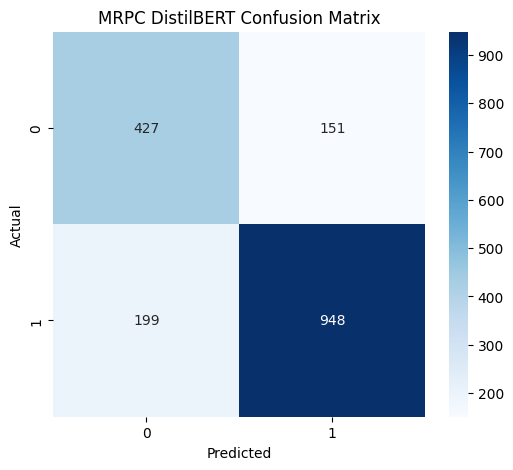

In [33]:
# Generate and save the confusion matrix

from src.evaluate import compute_confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = compute_confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("MRPC DistilBERT Confusion Matrix")

plt.savefig(
    "results/plots/mrpc_confusion_matrix(DistilBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

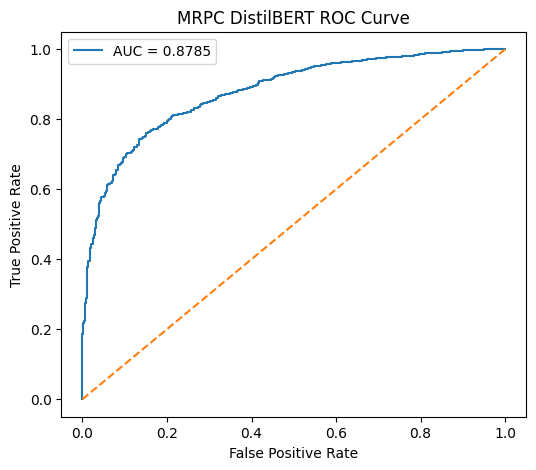

In [34]:
# Generate and save the ROC curve

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("MRPC DistilBERT ROC Curve")

plt.legend()

plt.savefig(
    "results/plots/mrpc_roc_curve(DistilBERT).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
# Log the DistilBERT experiment

from datetime import datetime

experiment = {
    "Experiment ID": "EXP-007",
    "Date": datetime.now().strftime("%Y-%m-%d"),
    "Phase": "Phase 3 - DistilBERT",
    "Model": "DistilBERT",
    "Dataset": "MRPC",
    "Train Split": len(train_df),
    "Validation Split": len(validation_df),
    "Test Split": len(test_df),
    "Batch Size": training_args.per_device_train_batch_size,
    "Learning Rate": training_args.learning_rate,
    "Epochs": training_args.num_train_epochs,
    "Accuracy": metrics["Accuracy"],
    "Precision": metrics["Precision"],
    "Recall": metrics["Recall"],
    "F1": metrics["F1"],
    "ROC-AUC": metrics["ROC-AUC"],
    "BLEU": "N/A",
    "ROUGE": "N/A",
    "BERTScore": "N/A",
    "Train Time": train_time,
    "Inference Time": inference_time,
    "Notes": "DistilBERT fine-tuned on MRPC",
    "Status": "Completed"
}

log_experiment(
    "logs/experiments.xlsx",
    experiment
)

In [38]:
# Generate the updated model comparison table

from src.reporting import ReportGenerator

report = ReportGenerator(
    "logs/experiments.xlsx"
)

comparison = report.generate_model_comparison()

comparison

,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time,Inference Time
6,DistilBERT,MRPC,0.797101,0.862602,0.826504,0.844167,0.878470,209.490797,4.201127
0,Logistic Regression,MRPC,0.727941,0.723404,0.974910,0.830534,0.675863,0.036566,0.000996
2,Logistic Regression,PAWS,0.556500,0.497691,0.274089,0.353499,0.548097,0.695119,0.009175
1,Logistic Regression,QQP,0.767549,0.722849,0.597850,0.654434,0.836436,3.161926,0.008341
3,SBERT + Logistic Regression,MRPC,0.629902,0.720690,0.749104,0.734622,0.561279,0.793760,0.003465
5,SBERT + Logistic Regression,PAWS,0.558625,0.502685,0.211642,0.297872,0.538899,2.329359,0.022624
4,SBERT + Logistic Regression,QQP,0.717462,0.662474,0.474169,0.552723,0.750352,36.028248,0.154764


In [39]:
# Compress the trained DistilBERT model

import shutil

shutil.make_archive(
    "mrpc_distilbert_model",
    "zip",
    "models/distilbert/mrpc"
)

'/kaggle/working/Paraphrase_Detection_Generation/mrpc_distilbert_model.zip'

In [40]:
# Compress all generated results

import shutil

shutil.make_archive(
    "mrpc_results",
    "zip",
    "results"
)

'/kaggle/working/Paraphrase_Detection_Generation/mrpc_results.zip'

In [41]:
# Compress the experiment logs

import shutil

shutil.make_archive(
    "experiment_logs",
    "zip",
    "logs"
)

'/kaggle/working/Paraphrase_Detection_Generation/experiment_logs.zip'